## Import packages needed.

In [ ]:
#!pip install rasterio keras_hub

## Set up environment.

In [ ]:
import os

# Because of the use of tf.image.ssim in the loss,
# this example requires TensorFlow. The rest of the code
# is backend-agnostic.
os.environ["KERAS_BACKEND"] = "tensorflow"

import numpy as np
from glob import glob
import matplotlib.pyplot as plt
import rasterio

import keras_hub
import tensorflow as tf
import keras
from keras import layers, ops

keras.config.disable_traceback_filtering()


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Only needed if taking the data from google drive. Otherwise, change to different location below.

In [ ]:
'''
from google.colab import drive
drive.mount('/content/drive')
'''

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Define hyperparameters

In [ ]:
IMAGE_SIZE = 256 # size to resize the image to.
BATCH_SIZE = 4
OUT_CLASSES = 1
TRAIN_SPLIT_RATIO = 0.80


## Create PyDataset objects

In [ ]:
data_dir="/content/drive/MyDrive/all_data" # change as needed

def load_paths(path, split_ratio):
    images = sorted(glob(os.path.join(path, "tile_*")))
    masks = sorted(glob(os.path.join(path, "mask_*")))
    len_ = int(len(images) * split_ratio)
    return (images[:len_], masks[:len_]), (images[len_:], masks[len_:])


class Dataset(keras.utils.PyDataset):
    def __init__(
        self,
        image_paths,
        mask_paths,
        img_size,
        out_classes,
        batch,
        shuffle=True,
        **kwargs,
    ):
        if shuffle:
            perm = np.random.permutation(len(image_paths))
            image_paths = [image_paths[i] for i in perm]
            mask_paths = [mask_paths[i] for i in perm]
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.img_size = img_size
        self.out_classes = out_classes
        self.batch_size = batch
        super().__init__(**kwargs)

    def __len__(self):
        return len(self.image_paths) // self.batch_size

    def __getitem__(self, idx):
        batch_x, batch_y = [], []
        for i in range(idx * self.batch_size, (idx + 1) * self.batch_size):
            x, y = self.preprocess(
                self.image_paths[i],
                self.mask_paths[i],
                self.img_size,
            )
            batch_x.append(x)
            batch_y.append(y)
        batch_x = np.stack(batch_x, axis=0)
        batch_y = np.stack(batch_y, axis=0)
        return batch_x, batch_y

    # Reads as rasterio objects and normalises images.
    def read_image(self, path, size):
        with rasterio.open(path) as src:
            img = src.read().astype(np.float32)  # (7, H, W)

        result = np.zeros_like(img)
        for i in range(img.shape[0]):
            band = img[i]
            p2, p98 = np.percentile(band, 2), np.percentile(band, 98)
            band = np.clip(band, p2, p98)
            band = (band - p2) / (p98 - p2 + 1e-9)
            result[i] = band

        result = np.transpose(result, (1, 2, 0))  # (H, W, 7)
        result = tf.image.resize(result, [size, size]).numpy()
        return result.astype(np.float32)

    # Reads masks as rasterio objects and rebinerises them.
    def read_mask(self, path, size):
        with rasterio.open(path) as src:
            mask = src.read(1).astype(np.float32)  # (H, W)

        mask = np.expand_dims(mask, axis=-1)  # (H, W, 1)
        mask = tf.image.resize(mask, [size, size]).numpy()
        mask = (mask > 0.5).astype(np.float32)
        return mask

    def preprocess(self, x_batch, y_batch, img_size):
        images = self.read_image(x_batch, img_size)
        masks = self.read_mask(y_batch, img_size)
        return images, masks

train_paths, val_paths = load_paths(data_dir, TRAIN_SPLIT_RATIO)

train_dataset = Dataset(
    train_paths[0], train_paths[1], IMAGE_SIZE, OUT_CLASSES, BATCH_SIZE, shuffle=True
)
val_dataset = Dataset(
    val_paths[0], val_paths[1], IMAGE_SIZE, OUT_CLASSES, BATCH_SIZE, shuffle=False
)


## Visualise the data

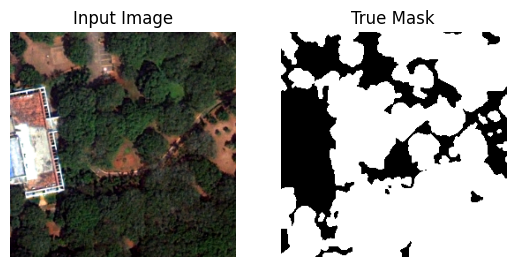

In [ ]:
def display(display_list):
    title = ["Input Image", "True Mask", "Predicted Mask"]

    for i in range(len(display_list)):
        plt.subplot(1, len(display_list), i + 1)
        plt.title(title[i])

        img = display_list[i]
        if img.shape[-1] == 7:
            # Use RGB bands (indices 4, 2, 1 = Red, Green, Blue) for display
            img = img[:, :, [3, 1, 0]]

        plt.imshow(img, cmap="gray")
        plt.axis("off")
    plt.show()


for image, mask in val_dataset:
    display([image[0], mask[0]])
    break


## Get an overview of the masks

In [ ]:
print(f"Unique values count: {len(np.unique((mask[0] * 255)))}")
print("Unique values:")
print(np.unique((mask[0] * 255)).astype(int))


Unique values count: 2
Unique values:
[  0 255]


## This is for the model structure.

In [ ]:
def basic_block(x_input, filters, stride=1, down_sample=None, activation=None):
    """Creates a residual(identity) block with two 3*3 convolutions."""
    residual = x_input

    x = layers.Conv2D(filters, (3, 3), strides=stride, padding="same", use_bias=False)(
        x_input
    )
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(filters, (3, 3), strides=(1, 1), padding="same", use_bias=False)(
        x
    )
    x = layers.BatchNormalization()(x)

    if down_sample is not None:
        residual = down_sample

    x = layers.Add()([x, residual])

    if activation is not None:
        x = layers.Activation(activation)(x)

    return x


def convolution_block(x_input, filters, dilation=1):
    """Apply convolution + batch normalization + relu layer."""
    x = layers.Conv2D(filters, (3, 3), padding="same", dilation_rate=dilation)(x_input)
    x = layers.BatchNormalization()(x)
    return layers.Activation("relu")(x)


def segmentation_head(x_input, out_classes, final_size):
    """Map each decoder stage output to model output classes."""
    x = layers.Conv2D(out_classes, kernel_size=(3, 3), padding="same")(x_input)

    if final_size is not None:
        x = layers.Resizing(final_size[0], final_size[1])(x)

    return x


def get_resnet_block(resnet, block_num):
    """Extract and return a ResNet-34 block."""
    extractor_levels = ["P2", "P3", "P4", "P5"]
    num_blocks = resnet.stackwise_num_blocks
    if block_num == 0:
        x = resnet.get_layer("pool1_pool").output
    else:
        x = resnet.pyramid_outputs[extractor_levels[block_num - 1]]
    y = resnet.get_layer(f"stack{block_num}_block{num_blocks[block_num]-1}_add").output
    return keras.models.Model(
        inputs=x,
        outputs=y,
        name=f"resnet_block{block_num + 1}",
    )


## This is the predictor module

In [ ]:
def basnet_predict(input_shape, out_classes):
    """BASNet Prediction Module, it outputs coarse label map."""
    filters = 64
    num_stages = 6

    x_input = layers.Input(input_shape)

    # -------------Encoder--------------
    x = layers.Conv2D(filters, kernel_size=(3, 3), padding="same")(x_input)

    resnet = keras_hub.models.ResNetBackbone(
        input_conv_filters=[64],
        input_conv_kernel_sizes=[7],
        stackwise_num_filters=[64, 128, 256, 512],
        stackwise_num_blocks=[3, 4, 6, 3],
        stackwise_num_strides=[1, 2, 2, 2],
        block_type="basic_block",
    )

    encoder_blocks = []
    for i in range(num_stages):
        if i < 4:  # First four stages are adopted from ResNet-34 blocks.
            x = get_resnet_block(resnet, i)(x)
            encoder_blocks.append(x)
            x = layers.Activation("relu")(x)
        else:  # Last 2 stages consist of three basic resnet blocks.
            x = layers.MaxPool2D(pool_size=(2, 2), strides=(2, 2))(x)
            x = basic_block(x, filters=filters * 8, activation="relu")
            x = basic_block(x, filters=filters * 8, activation="relu")
            x = basic_block(x, filters=filters * 8, activation="relu")
            encoder_blocks.append(x)

    # -------------Bridge-------------
    x = convolution_block(x, filters=filters * 8, dilation=2)
    x = convolution_block(x, filters=filters * 8, dilation=2)
    x = convolution_block(x, filters=filters * 8, dilation=2)
    encoder_blocks.append(x)

    # -------------Decoder-------------
    decoder_blocks = []
    for i in reversed(range(num_stages)):
        if i != (num_stages - 1):  # Except first, scale other decoder stages.
            shape = x.shape
            x = layers.Resizing(shape[1] * 2, shape[2] * 2)(x)

        x = layers.concatenate([encoder_blocks[i], x], axis=-1)
        x = convolution_block(x, filters=filters * 8)
        x = convolution_block(x, filters=filters * 8)
        x = convolution_block(x, filters=filters * 8)
        decoder_blocks.append(x)

    decoder_blocks.reverse()  # Change order from last to first decoder stage.
    decoder_blocks.append(encoder_blocks[-1])  # Copy bridge to decoder.

    # -------------Side Outputs--------------
    decoder_blocks = [
        segmentation_head(decoder_block, out_classes, input_shape[:2])
        for decoder_block in decoder_blocks
    ]

    return keras.models.Model(inputs=x_input, outputs=decoder_blocks)


## This is the residual refinement module

In [ ]:
def basnet_rrm(base_model, out_classes):
    """BASNet Residual Refinement Module(RRM) module, output fine label map."""
    num_stages = 4
    filters = 64

    x_input = base_model.output[0]

    # -------------Encoder--------------
    x = layers.Conv2D(filters, kernel_size=(3, 3), padding="same")(x_input)

    encoder_blocks = []
    for _ in range(num_stages):
        x = convolution_block(x, filters=filters)
        encoder_blocks.append(x)
        x = layers.MaxPool2D(pool_size=(2, 2), strides=(2, 2))(x)

    # -------------Bridge--------------
    x = convolution_block(x, filters=filters)

    # -------------Decoder--------------
    for i in reversed(range(num_stages)):
        shape = x.shape
        x = layers.Resizing(shape[1] * 2, shape[2] * 2)(x)
        x = layers.concatenate([encoder_blocks[i], x], axis=-1)
        x = convolution_block(x, filters=filters)

    x = segmentation_head(x, out_classes, None)  # Segmentation head.

    # ------------- refined = coarse + residual
    x = layers.Add()([x_input, x])  # Add prediction + refinement output

    return keras.models.Model(inputs=[base_model.input], outputs=[x])


## Combine the predictor and refinement modules

In [ ]:
class BASNet(keras.Model):
    def __init__(self, input_shape, out_classes):
        """BASNet, it's a combination of two modules
        Prediction Module and Residual Refinement Module(RRM)."""

        # Prediction model.
        predict_model = basnet_predict(input_shape, out_classes)
        # Refinement model.
        refine_model = basnet_rrm(predict_model, out_classes)

        output = refine_model.outputs  # Combine outputs.
        output.extend(predict_model.output)

        # Activations.
        output = [layers.Activation("sigmoid")(x) for x in output]
        super().__init__(inputs=predict_model.input, outputs=output)

        self.smooth = 1.0e-9
        # Binary Cross Entropy loss.
        self.cross_entropy_loss = keras.losses.BinaryCrossentropy()
        # Structural Similarity Index value.
        self.ssim_value = tf.image.ssim
        # Jaccard / IoU loss.
        self.iou_value = self.calculate_iou

    def calculate_iou(
        self,
        y_true,
        y_pred,
    ):
        """Calculate intersection over union (IoU) between images."""
        intersection = ops.sum(ops.abs(y_true * y_pred), axis=[1, 2, 3])
        union = ops.sum(y_true, [1, 2, 3]) + ops.sum(y_pred, [1, 2, 3])
        union = union - intersection
        return ops.mean((intersection + self.smooth) / (union + self.smooth), axis=0)

    def compute_loss(self, x, y_true, y_pred, sample_weight=None, training=False):
        y_true = tf.cast(y_true, tf.float32)
        total = 0.0
        for y_pred_i in y_pred:
            y_pred_i = tf.cast(y_pred_i, tf.float32)  # cast each prediction too

            cross_entropy_loss = self.cross_entropy_loss(y_true, y_pred_i)

            ssim_value = self.ssim_value(y_true, y_pred_i, max_val=1)  # was y_pred, should be y_pred_i
            ssim_loss = ops.mean(1 - ssim_value + self.smooth, axis=0)

            iou_value = self.iou_value(y_true, y_pred_i)  # same fix here
            iou_loss = 1 - iou_value

            total += cross_entropy_loss + ssim_loss + iou_loss
        return total


## Hybrid loss

In [ ]:
basnet_model = BASNet(
    input_shape=[IMAGE_SIZE, IMAGE_SIZE, 7],
    out_classes=OUT_CLASSES
)  # Create model.
basnet_model.summary()  # Show model summary.

optimizer = keras.optimizers.Adam(learning_rate=1e-4, epsilon=1e-8)
# Compile model.
basnet_model.compile(
    optimizer=optimizer,
    metrics=[keras.metrics.MeanAbsoluteError(name="mae") for _ in basnet_model.outputs],
)


Model: "bas_net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 7)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      4,096 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet_block1       │ (None, 256, 256,  │    222,720 │ conv2d[0][0]      │
│ (Functional)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ resnet_block1[0]… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet_block2       │ (None, 128, 128,  │  1,118,720 │ activation[0][0]  │
│ (Functional)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ resnet_block2[0]… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet_block3       │ (None, 64, 64,    │  6,829,056 │ activation_1[0][… │
│ (Functional)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ resnet_block3[0]… │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet_block4       │ (None, 32, 32,    │ 13,121,536 │ activation_2[0][… │
│ (Functional)        │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 32, 32,    │          0 │ resnet_block4[0]… │
│ (Activation)        │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 16, 16,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 16, 16,    │  2,359,296 │ max_pooling2d[0]… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 16, 16,    │      2,048 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Activation)        │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 16,    │  2,359,296 │ activation_4[0][… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │      2,048 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 16, 16,    │          0 │ batch_normalizat

 Total params: 108,889,096 (415.38 MB)

 Trainable params: 108,837,256 (415.18 MB)

 Non-trainable params: 51,840 (202.50 KB)

## Train

Epoch 1/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 698s 6s/step - activation_46_mae: 0.1659 - loss: 13.6929 - val_activation_46_mae: 0.2288 - val_loss: 17.9637
Epoch 2/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 336s 5s/step - activation_46_mae: 0.1275 - loss: 10.9524 - val_activation_46_mae: 0.1468 - val_loss: 20.1768
Epoch 3/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 339s 5s/step - activation_46_mae: 0.1143 - loss: 10.2022 - val_activation_46_mae: 0.1482 - val_loss: 12.9028
Epoch 4/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 340s 5s/step - activation_46_mae: 0.1092 - loss: 9.7532 - val_activation_46_mae: 0.1062 - val_loss: 10.0810
Epoch 5/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 338s 5s/step - activation_46_mae: 0.1062 - loss: 9.4118 - val_activation_46_mae: 0.0944 - val_loss: 9.7590
Epoch 6/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 337s 5s/step - activation_46_mae: 0.1004 - loss: 9.0516 - val_activation_46_mae: 0.0910 - val_loss: 8.5847
Epoch 7/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 338s 5s/step - activation_46_mae: 0.0829 - loss: 8.1497 - val_activation_46_mae: 0.16

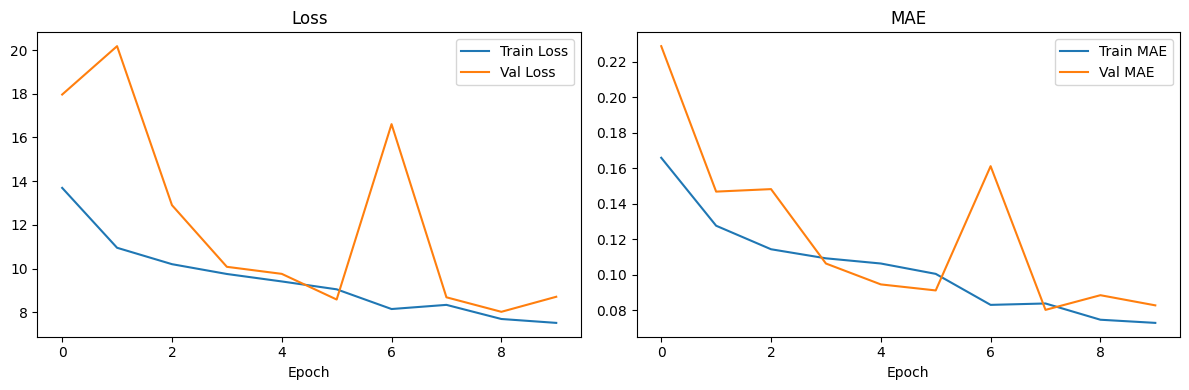

In [ ]:
#basnet_model.fit(train_dataset, validation_data=val_dataset, epochs=10)
history = basnet_model.fit(train_dataset, validation_data=val_dataset, epochs=10)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['activation_46_mae'], label='Train MAE')
plt.plot(history.history['val_activation_46_mae'], label='Val MAE')
plt.title('MAE')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

## Visualise predictions. This was supposed to use some pretrained wieghts, but the weights were determined for RGB images not multispectral so we didn't end up using it. It's a simple output normalisation function here.

In [ ]:

def normalize_output(prediction):
    max_value = np.max(prediction)
    min_value = np.min(prediction)
    return (prediction - min_value) / (max_value - min_value)


## Make predictions on the validation data.

/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


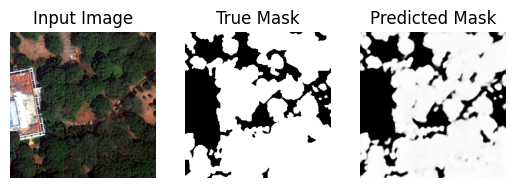

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


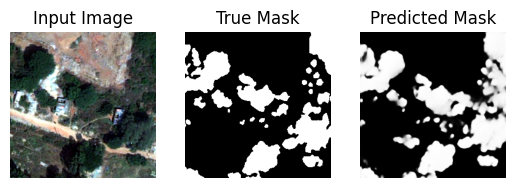

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


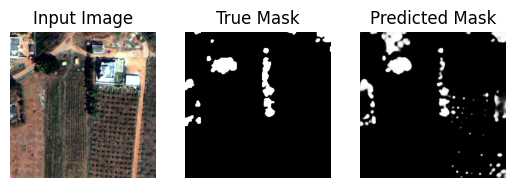

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


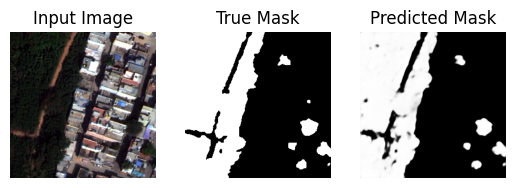

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


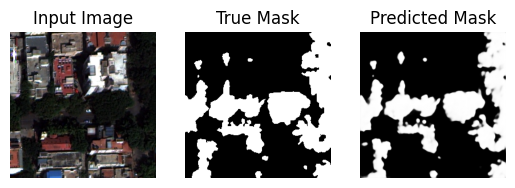

In [ ]:
for (image, mask), _ in zip(val_dataset, range(5)):
    pred_mask = basnet_model.predict(image)
    display([image[0], mask[0], normalize_output(pred_mask[0][0])])


## Get final metrics.

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

all_preds = []
all_true = []

for (image, mask), _ in zip(val_dataset, range(len(val_dataset))):
    pred_mask = basnet_model.predict(image, verbose=0)
    normalized = normalize_output(pred_mask[0])
    pred_binary = (normalized > 0.5).astype(np.float32)

    all_preds.append(pred_binary.flatten())
    all_true.append(mask.flatten())

all_preds = np.concatenate(all_preds)
all_true = np.concatenate(all_true)

print(f"Precision: {precision_score(all_true, all_preds):.4f}")
print(f"Recall:    {recall_score(all_true, all_preds):.4f}")
print(f"F1:        {f1_score(all_true, all_preds):.4f}")
print(f"Accuracy:  {accuracy_score(all_true, all_preds):.4f}")

Precision: 0.8425
Recall:    0.8743
F1:        0.8581
Accuracy:  0.9255
